In [1]:
import sys
from pathlib import Path

# add src directory to python path
sys.path.append(str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
from sklearn import __version__ as sk_ver
print('sklearn:', sk_ver)

from random_forest import tools as rf_tools

sklearn: 1.7.2


#### Phase 01 : Import data

In [2]:
pre_processed = pd.read_parquet('../src/data/pre_processed/features.parquet')

In [3]:
pre_processed.head(10)

,Elo_diff,Elo_mean,N_min,elo_surface_diff,elo_effective_diff,spec_diff,surface_exp_min,log_pts_diff,log_rank_diff,Surface_Clay,Surface_Grass,Surface_Hard,Best_of_5,Winner
0,0.000000,1500.000000,0.0,0.000000,0.000000,0.000000,0,NaN,0.585902,0.0,0.0,1.0,0,0
1,0.000000,1500.000000,0.0,0.000000,0.000000,0.000000,0,NaN,0.659246,0.0,0.0,1.0,0,0
2,0.000000,1500.000000,0.0,0.000000,0.000000,0.000000,0,NaN,-0.037041,0.0,0.0,1.0,0,1
3,0.000000,1500.000000,0.0,0.000000,0.000000,0.000000,0,NaN,0.843429,0.0,0.0,1.0,0,1
4,0.000000,1500.000000,0.0,0.000000,0.000000,0.000000,0,NaN,-1.749200,0.0,0.0,1.0,0,0
5,0.000000,1500.000000,0.0,0.000000,0.000000,0.000000,0,NaN,1.196251,0.0,0.0,1.0,0,0
6,-65.663195,1467.168402,0.0,-16.000000,-8.200000,-0.002000,0,NaN,2.151762,0.0,0.0,1.0,0,1
7,-77.927462,1461.036269,0.0,-16.377554,-8.393496,-0.002047,0,NaN,-2.095971,0.0,0.0,1.0,0,1
8,0.000000,1500.000000,0.0,0.000000,0.000000,0.000000,0,NaN,0.116724,0.0,0.0,1.0,0,0
9,-6.783409,1503.391704,0.0,0.402330,0.211223,0.000101,0,NaN,0.240054,0.0,0.0,1.0,0,0


#### Phase 02: Split train/test

In [4]:
y_name = 'Winner'
X_train, X_test, y_train, y_test = rf_tools.split_data(pre_processed, y_name)

In [5]:
print('X train shape:', X_train.shape)
print('X test  shape:', X_test .shape)
print('y train shape:', y_train.shape)
print('y test  shape:', y_test .shape)

X train shape: (54705, 13)
X test  shape: (13677, 13)
y train shape: (54705,)
y test  shape: (13677,)


In [6]:
from sklearn.model_selection import train_test_split

# Chronological split: last 20% of train becomes validation (no shuffle for time-series)
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, shuffle=False)

#### Phase 03 : Train

In [7]:
from xgb.model import fit_sym, predict_sym
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import log_loss

grid = ParameterGrid({'max_depth': [3, 4, 5], 'learning_rate': [0.03, 0.05, 0.1], 'n_estimators': [100, 200, 300], 'reg_lambda': [1., 2., 3.]})

In [8]:
from tqdm import tqdm

results = []
for g in tqdm(grid, desc="Grid search"):
    ll = log_loss(y_val, predict_sym(fit_sym(X_tr, y_tr, **g), X_val))
    results.append((ll, g))
    tqdm.write(f"logloss={ll:.5f}  {g}")   # keeps the bar intact

best_ll, best = min(results, key=lambda t: t[0])
print("\nBest:", best, f"logloss={best_ll:.5f}")

Grid search:   0%|          | 0/81 [00:00<?, ?it/s]

Grid search:   1%|          | 1/81 [00:05<07:09,  5.36s/it]

logloss=0.61546  {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 100, 'reg_lambda': 1.0}


Grid search:   2%|▏         | 2/81 [00:05<03:22,  2.56s/it]

logloss=0.61550  {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 100, 'reg_lambda': 2.0}


...

logloss=0.62017  {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'reg_lambda': 1.0}


Grid search:  99%|█████████▉| 80/81 [10:29<00:09,  9.59s/it]

logloss=0.62050  {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'reg_lambda': 2.0}


Grid search: 100%|██████████| 81/81 [10:49<00:00,  8.01s/it]

logloss=0.62029  {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'reg_lambda': 3.0}

Best: {'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 100, 'reg_lambda': 2.0} logloss=0.61397


In [9]:
model = fit_sym(X_train, y_train, **best)

#### Phase 04 : Evaluation

In [10]:
from sklearn.metrics import log_loss, roc_auc_score, brier_score_loss, accuracy_score

p_test = model.predict_proba(X_test)[:, 1]
print(f"test logloss: {log_loss(y_test, p_test)}")
print(f"test auc    : {roc_auc_score(y_test, p_test)}")
print(f"Test Brier  : {brier_score_loss(y_test, p_test)}")
print(f"Test Acc    : {accuracy_score(y_test, p_test > 0.5)}")

test logloss: 0.6143278903793853
test auc    : 0.7170414241976524
Test Brier  : 0.2136293696877742
Test Acc    : 0.6511661914162462


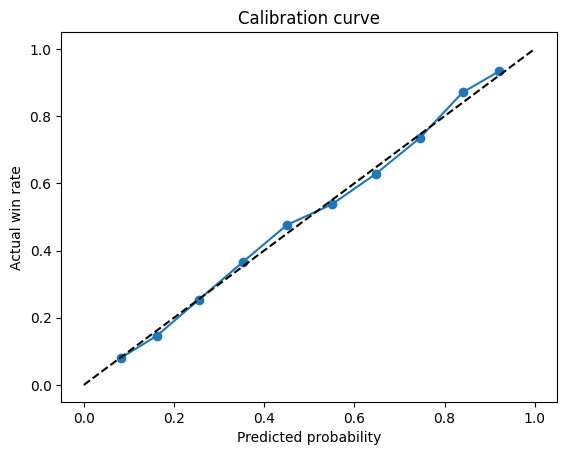

In [11]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, p_test, n_bins=10)
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Predicted probability'); plt.ylabel('Actual win rate')
plt.title('Calibration curve')
plt.show()